In [2]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.style.use("seaborn-v0_8")

#read data
df = pd.read_csv('../data/gas_price_2526.csv')

df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()

df = df[["daily price"]]

print(df.head())
print(df.index.min(), "→", df.index.max())
print("Columns:", df.columns.tolist())


            daily price
date                   
2025-01-19        39.85
2025-01-20        37.21
2025-01-21        37.33
2025-01-22        37.85
2025-01-23        35.70
2025-01-19 00:00:00 → 2026-06-02 00:00:00
Columns: ['daily price']


C:\Users\sagal\AppData\Local\Temp\ipykernel_35056\4127333932.py:14: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"])


In [4]:
#split the data

def split_sarima_data(df, train_ratio=0.80):
    n = len(df)
    split_idx = int(n * train_ratio)

    train_df = df.iloc[:split_idx].copy()
    test_df  = df.iloc[split_idx:].copy()
    
    print(f"Total rows:   {n}")
    print(f"Train rows:   {len(train_df)}")
    print(f"Test rows:    {len(test_df)}")
    print(f"Train range:  {train_df.index.min().date()} → {train_df.index.max().date()}")
    print(f"Test range:   {test_df.index.min().date()} → {test_df.index.max().date()}")

    return train_df, test_df

train_df, test_df = split_sarima_data(df)


Total rows:   500
Train rows:   400
Test rows:    100
Train range:  2025-01-19 → 2026-02-22
Test range:   2026-02-23 → 2026-06-02


In [5]:
#build sarima

def build_sarima_model(order=(1,1,1), seasonal_order=(1,1,1,12)):
    print(f"Building SARIMA model with order={order} and seasonal_order={seasonal_order}")
    return order, seasonal_order


In [7]:
#fit sarima
def fit_sarima(train_df, order, seasonal_order):

    model = SARIMAX(
        train_df["daily price"],
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(disp=False)
    print("SARIMA model fitted successfully.")
    return fitted_model

#default parameters
order, seasonal_order = build_sarima_model(
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = fit_sarima(train_df, order, seasonal_order)


Building SARIMA model with order=(1, 1, 1) and seasonal_order=(1, 1, 1, 12)


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMA model fitted successfully.


In [8]:
#predict on test

def sarima_predict_test(fitted_model, test_df):

    start = len(fitted_model.data.endog)          # first forecast index
    end   = start + len(test_df) - 1              # last forecast index

    forecast_res = fitted_model.get_forecast(steps=len(test_df))

    yhat = forecast_res.predicted_mean
    ci   = forecast_res.conf_int(alpha=0.05)      # 95% CI

    forecast_df = pd.DataFrame({
        "ds": test_df.index,
        "yhat": yhat.values,
        "yhat_lower": ci.iloc[:, 0].values,
        "yhat_upper": ci.iloc[:, 1].values
    })

    return forecast_df

sarima_test_forecast = sarima_predict_test(sarima_model, test_df)
sarima_test_forecast.head()


,ds,yhat,yhat_lower,yhat_upper
0,2026-02-23,58.883910,56.834710,60.933110
1,2026-02-24,58.794327,54.592193,62.996461
2,2026-02-25,58.899274,53.420508,64.378040
3,2026-02-26,59.071811,52.554313,65.589309
4,2026-02-27,59.256438,51.845026,66.667850


In [9]:
#evaluate model

def evaluate_sarima(test_df, forecast_df):

    merged = pd.DataFrame({
        "y_true": test_df["daily price"].values,
        "y_pred": forecast_df["yhat"].values
    })

    rmse = np.sqrt(mean_squared_error(merged["y_true"], merged["y_pred"]))
    mae  = mean_absolute_error(merged["y_true"], merged["y_pred"])
    mape = np.mean(np.abs((merged["y_true"] - merged["y_pred"]) / merged["y_true"])) * 100

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")

    return rmse, mae, mape

sarima_rmse, sarima_mae, sarima_mape = evaluate_sarima(test_df, sarima_test_forecast)


RMSE: 13.4878
MAE:  10.9867
MAPE: 14.28%


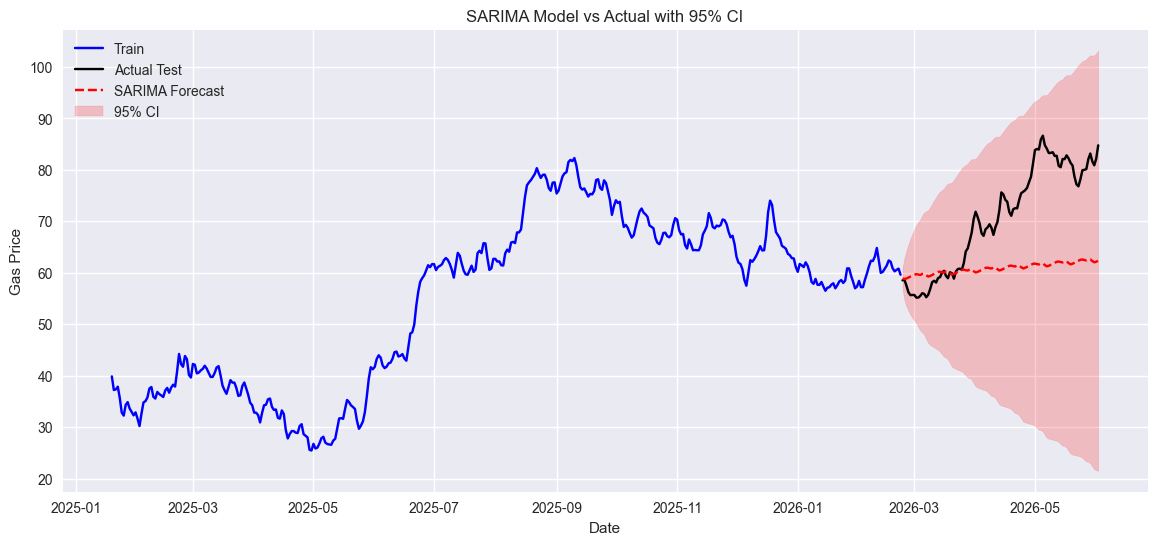

In [10]:
#plot

def plot_sarima_results(train_df, test_df, forecast_df):

    plt.figure(figsize=(14,6))
    plt.plot(train_df.index, train_df["daily price"], label="Train", color="blue")
    plt.plot(test_df.index, test_df["daily price"], label="Actual Test", color="black")
    plt.plot(forecast_df["ds"], forecast_df["yhat"], label="SARIMA Forecast", color="red", linestyle="--")

    plt.fill_between(
        forecast_df["ds"],
        forecast_df["yhat_lower"],
        forecast_df["yhat_upper"],
        color="red",
        alpha=0.2,
        label="95% CI"
    )

    plt.title("SARIMA Model vs Actual with 95% CI")
    plt.xlabel("Date")
    plt.ylabel("Gas Price")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_sarima_results(train_df, test_df, sarima_test_forecast)


In [ ]:
#refit sarima on full data

def refit_sarima_full(df, order, seasonal_order):
    """
    Refit SARIMA on the full dataset for future forecasting.
    """
    print("Refitting SARIMA on full dataset...")

    model = SARIMAX(
        df["daily price"],
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_full = model.fit(disp=False)
    print("Full SARIMA model fitted.")
    return fitted_full

sarima_full_model = refit_sarima_full(df, order, seasonal_order)


Refitting SARIMA on full dataset...


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Full SARIMA model fitted.


In [ ]:
#24 month forecast

def sarima_forecast_future(fitted_model, periods=730):
    forecast_res = fitted_model.get_forecast(steps=periods)
    yhat = forecast_res.predicted_mean
    ci   = forecast_res.conf_int(alpha=0.05)

    future_index = pd.date_range(
        start=fitted_model.data.dates[-1] + pd.Timedelta(days=1),
        periods=periods,
        freq="D"
    )

    forecast_df = pd.DataFrame({
        "ds": future_index,
        "yhat": yhat.values,
        "yhat_lower": ci.iloc[:, 0].values,
        "yhat_upper": ci.iloc[:, 1].values
    })

    return forecast_df

sarima_future_forecast = sarima_forecast_future(sarima_full_model, periods=730)
sarima_future_forecast.head()


,ds,yhat,yhat_lower,yhat_upper
0,2026-06-03,86.179128,84.174437,88.183819
1,2026-06-04,86.131397,82.025455,90.237339
2,2026-06-05,86.405212,81.060633,91.749791
3,2026-06-06,86.514490,80.159635,92.869345
4,2026-06-07,86.599117,79.374729,93.823505


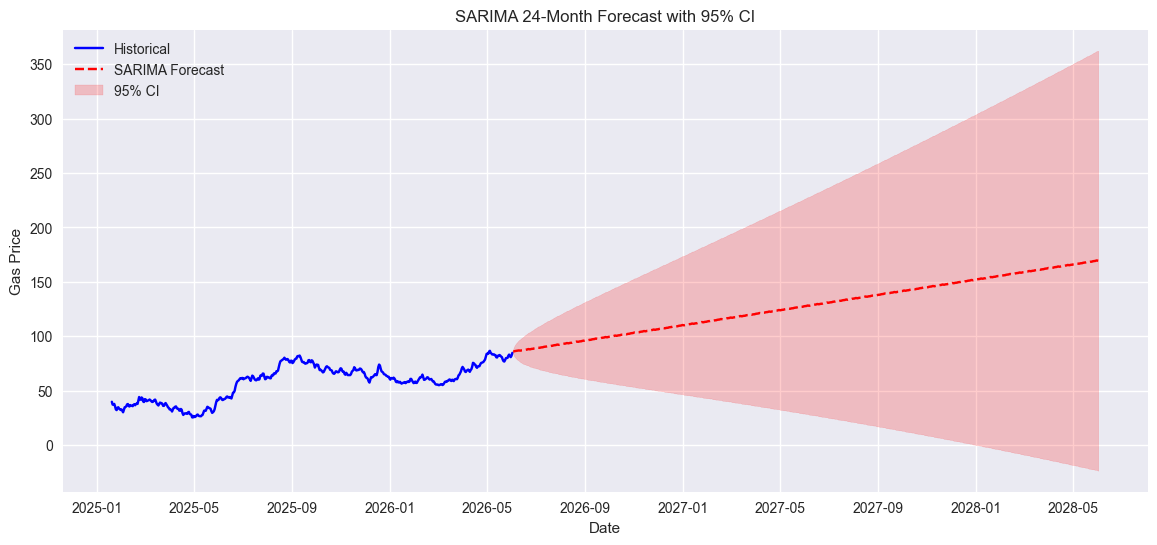

In [ ]:
#full plot

def plot_sarima_future(df, forecast_df):
    plt.figure(figsize=(14,6))
    plt.plot(df.index, df["daily price"], label="Historical", color="blue")

    # Forecast
    plt.plot(forecast_df["ds"], forecast_df["yhat"], label="SARIMA Forecast", color="red", linestyle="--")

    # CI
    plt.fill_between(
        forecast_df["ds"],
        forecast_df["yhat_lower"],
        forecast_df["yhat_upper"],
        color="red",
        alpha=0.2,
        label="95% CI"
    )

    plt.title("SARIMA 24-Month Forecast with 95% CI")
    plt.xlabel("Date")
    plt.ylabel("Gas Price")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_sarima_future(df, sarima_future_forecast)
